In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, datasets, models
import matplotlib.pyplot as plt
import numpy as np

In [25]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [26]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [28]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

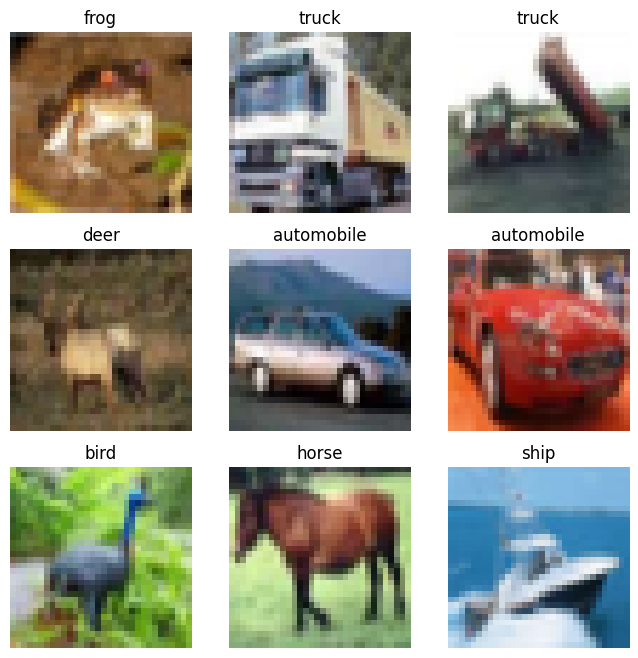

In [29]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

In [30]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [31]:
model = keras.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

In [32]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:

history = model.fit(x_train,y_train,epochs=25,
                    validation_data=(x_test,y_test))

Epoch 1/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - accuracy: 0.4088 - loss: 1.6587 - val_accuracy: 0.4644 - val_loss: 1.5313
Epoch 2/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.4970 - loss: 1.4028 - val_accuracy: 0.5295 - val_loss: 1.3378
Epoch 3/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5448 - loss: 1.2955 - val_accuracy: 0.6151 - val_loss: 1.0929
Epoch 4/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5713 - loss: 1.2200 - val_accuracy: 0.6382 - val_loss: 1.0422
Epoch 5/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.5920 - loss: 1.1694 - val_accuracy: 0.5767 - val_loss: 1.2327
Epoch 6/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6102 - loss: 1.1213 - val_accuracy: 0.5762 - val_loss: 1.2729
Epoch 7/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6258 - loss: 1.0830 - val_accuracy: 0.6573 - val_loss: 1.0146
Epoch 8/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6356 -

In [34]:
test_loss, test_acc = model.evaluate(x_test,y_test)
print("Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7448 - loss: 0.7608
Accuracy: 0.7447999715805054


In [35]:
predictions = model.predict(x_test)

for i in range(5):
    print("Predicted:", class_names[np.argmax(predictions[i])],
          "| Actual:", class_names[y_test[i][0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted: cat | Actual: cat
Predicted: ship | Actual: ship
Predicted: ship | Actual: ship
Predicted: airplane | Actual: airplane
Predicted: frog | Actual: frog


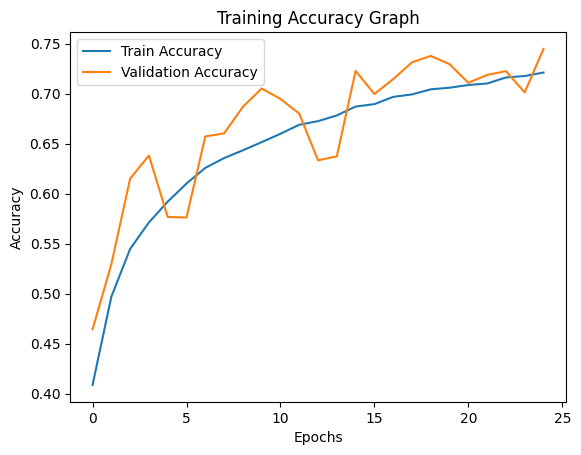

In [36]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()